# 03 — Confidence, ipTM, and the affinity head

The question: given a target–drug pair that Boltz-2 has modelled, does any of its output
separate the pairs the 2012 assay called active from the ones it called inactive?

The answer depends entirely on which output you read, and the difference is the whole
result.

In [1]:
import sys, os
from pathlib import Path

# Work from the repository root wherever the notebook is launched from.
_root = Path.cwd().resolve()
while not (_root / "src" / "offtarget").exists():
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / "src"))

import pandas as pd
from offtarget.metrics import auc_table, stratified_auc, bootstrap_auc_ci, per_target_auc
from offtarget import figures as F
pd.set_option("display.width", 140)
audited = pd.read_parquet("data/processed/pairs_audited.parquet")
audited = audited[audited.label.notna()]
print(f"n = {len(audited)}   assay-active = {int((audited.label == 'assay_active').sum())}   "
      f"assay-inactive = {int((audited.label == 'assay_inactive').sum())}   "
      f"targets = {audited.Target.nunique()}")

n = 708   assay-active = 147   assay-inactive = 561   targets = 63


## Why stratify

Pooled AUC across this table is close to meaningless. Targets differ enormously in how many
of their tested drugs turned out to be active, so a score that has learned nothing except
*which target this is* still ranks well pooled.

In [2]:
hit = audited.groupby("Target").agg(n=("drug", "size"),
                                    active=("label", lambda s: (s == "assay_active").sum()))
hit["hit_rate"] = hit.active / hit.n
hit.sort_values("hit_rate", ascending=False).head(8)

,n,active,hit_rate
Target,,,
KCNH2,1,1,1.000000
NR3C1,7,6,0.857143
PGR,11,8,0.727273
CHRM2,7,5,0.714286
ADRA1A,13,9,0.692308
CHRM1,6,4,0.666667
OPRK1,13,7,0.538462
HRH1,10,5,0.500000


Stratifying within target removes that channel. Only targets contributing both classes can
say anything about ranking — 34 of the 63 here.

In [3]:
table = auc_table(audited)
table.round(3)

,score,pooled_auc,within_target_auc,targets_used
0,Confidence (0.8*pLDDT + 0.2*ipTM),0.563,0.527,34
1,ipTM (interface only),0.592,0.486,34
2,Affinity probability,0.731,0.683,34
3,-Affinity score (predicted log affinity),0.771,0.710,34


| Score | Pooled | Within-target |
|---|---|---|
| Confidence (0.8·pLDDT + 0.2·ipTM) | 0.563 | **0.527** |
| ipTM (interface only) | 0.592 | **0.486** |
| Affinity probability | 0.731 | 0.683 |
| −Affinity score | 0.771 | **0.710** |

**Both structural confidence metrics sit at chance. Both affinity outputs discriminate.**

The obvious objection to an earlier version of this result was that Boltz-2's confidence is
`0.8·pLDDT + 0.2·ipTM` and therefore dominated by fold quality — that the interface metric,
ipTM, would tell a different story. It does tell a different story: ipTM is the *worst* of
the four. It is not that the wrong number was read.

## How much of this is noise

The interval resamples targets, not pairs. Pairs within a target share a protein, a
construct and an oligomeric state; resampling rows would treat 34 targets' worth of
information as 708 independent observations.

In [4]:
ci = pd.DataFrame([{"score": name, "within-target AUC": round(stratified_auc(audited, c)[0], 3),
                    "95% CI": tuple(round(v, 3) for v in bootstrap_auc_ci(audited, c))}
                   for c, name in
                   [("confidence", "Confidence"), ("iptm", "ipTM"),
                    ("affinity_probability", "Affinity probability"),
                    ("neg_affinity_score", "-Affinity score")]])
ci

,score,within-target AUC,95% CI
0,Confidence,0.527,"(0.445, 0.613)"
1,ipTM,0.486,"(0.429, 0.547)"
2,Affinity probability,0.683,"(0.61, 0.756)"
3,-Affinity score,0.710,"(0.644, 0.77)"


Both confidence intervals include 0.5. Neither affinity interval does. The intervals are
wide — the whole table rests on 34 proteins — and that width is part of the result.

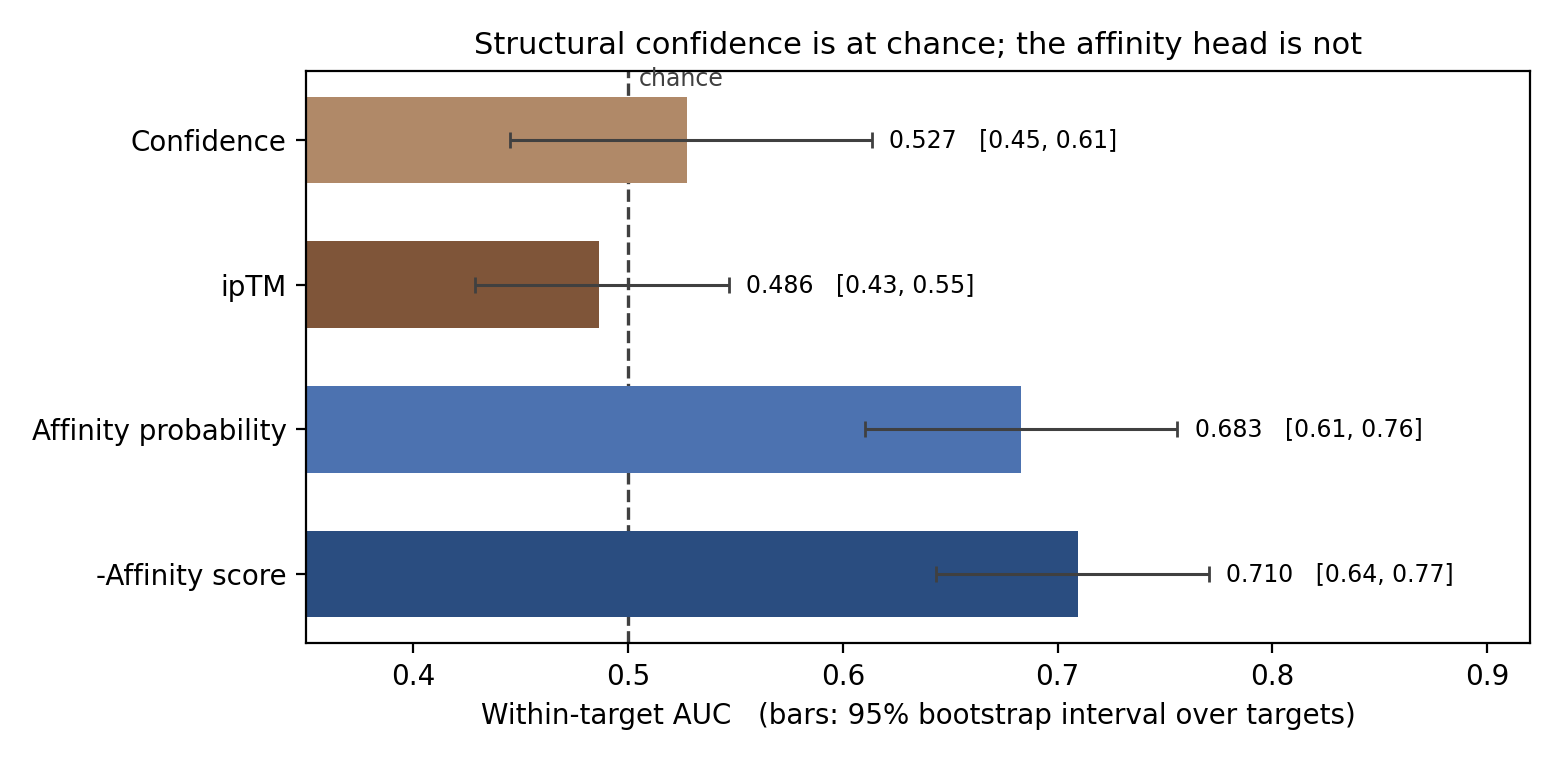

In [5]:
F.roc_panel(audited, Path("results/figures/fig1_roc_confidence_vs_affinity.png"))
F.within_target_bars(audited, Path("results/figures/fig2_within_target_auc.png"))
from IPython.display import Image, display
display(Image("results/figures/fig2_within_target_auc.png"))

## Per target

The pooled figure hides that ipTM is below chance on more targets than it is above.

In [6]:
per = per_target_auc(audited, "iptm").merge(
    per_target_auc(audited, "neg_affinity_score"), on="Target", suffixes=("_iptm", "_affinity"))
print(f"targets where ipTM beats chance:     {int((per.auc_iptm > 0.5).sum())} of {len(per)}")
print(f"targets where affinity beats chance: {int((per.auc_affinity > 0.5).sum())} of {len(per)}")
per.sort_values("weight_iptm", ascending=False)[
    ["Target", "n_iptm", "n_pos_iptm", "auc_iptm", "auc_affinity"]].head(12).round(3)

targets where ipTM beats chance:     14 of 34
targets where affinity beats chance: 30 of 34


,Target,n_iptm,n_pos_iptm,auc_iptm,auc_affinity
25,OPRM1,34,6,0.595,0.810
5,ADRB2,35,5,0.333,0.860
11,DRD3,22,8,0.438,0.652
3,ADRA2C,21,9,0.444,0.759
18,HTR2A,21,8,0.577,0.452
19,HTR2B,22,6,0.490,0.750
9,DRD1,27,4,0.348,0.576
1,ADRA2A,20,7,0.747,0.615
2,ADRA2B,19,6,0.436,0.500
20,HTR2C,27,3,0.542,0.917


## Robustness: dropping the target with the known broken input

One target, ADRA2A, was modelled against a 32-residue fragment of a helix (see notebook 01).
Removing its 20 rows changes nothing that matters.

In [7]:
primary = pd.read_parquet("data/processed/pairs.parquet")
primary = primary[primary.label.notna()]
comparison = auc_table(audited)[["score", "within_target_auc"]].merge(
    auc_table(primary)[["score", "within_target_auc"]], on="score",
    suffixes=(" (n=708, as audited)", " (n=688, ADRA2A dropped)"))
comparison.round(3)

,score,"within_target_auc (n=708, as audited)","within_target_auc (n=688, ADRA2A dropped)"
0,Confidence (0.8*pLDDT + 0.2*ipTM),0.527,0.511
1,ipTM (interface only),0.486,0.471
2,Affinity probability,0.683,0.684
3,-Affinity score (predicted log affinity),0.710,0.715


## Disagreement with the earlier extraction

The master workbook used above is a later, ipTM-carrying extraction. The repository also
holds the earlier one, `boltzresults_individual.xlsx`, where the two sequence arms are in
separate sheets. Running the same measure there:

In [8]:
xl = pd.ExcelFile("data/boltz_outputs/boltzresults_individual.xlsx")

def arm(true_sheet, false_sheet):
    frames = []
    for sheet, lab in [(true_sheet, "assay_active"), (false_sheet, "assay_inactive")]:
        d = xl.parse(sheet)
        d.columns = [str(c).strip() for c in d.columns]
        d = d.rename(columns={"Confidence_score": "confidence", "Affinity": "affinity",
                              "Affinity_score": "affinity_probability",
                              "Affinity, boltz2": "affinity"})
        d["Target"] = d.Target.astype(str).str.strip().str.upper()
        d["label"] = lab
        for c in ["confidence", "affinity", "affinity_probability"]:
            d[c] = pd.to_numeric(d.get(c), errors="coerce")
        frames.append(d[["Target", "Drug", "confidence", "affinity",
                         "affinity_probability", "label"]])
    out = pd.concat(frames, ignore_index=True)
    out["neg_affinity_score"] = -out.affinity
    return out

rows = []
for name, (t, f) in {"PDB arm": ("TruePDB", "FalsePDB"),
                     "UniProt arm": ("TrueUni", "FalseUni")}.items():
    d = arm(t, f)
    for c in ["confidence", "affinity_probability", "neg_affinity_score"]:
        dd = d.dropna(subset=[c])
        auc, used = stratified_auc(dd, c)
        rows.append({"extraction": name, "score": c, "within-target AUC": round(auc, 3),
                     "n": len(dd), "targets": used})
pd.DataFrame(rows)

,extraction,score,within-target AUC,n,targets
0,PDB arm,confidence,0.509,400,30
1,PDB arm,affinity_probability,0.653,396,29
2,PDB arm,neg_affinity_score,0.701,396,29
3,UniProt arm,confidence,0.600,671,35
4,UniProt arm,affinity_probability,0.660,667,33
5,UniProt arm,neg_affinity_score,0.707,667,33


The two extractions agree on the finding and not on the digits: confidence 0.509 (PDB) and
0.600 (UniProt) against 0.527 for the merged confidence column, affinity 0.701–0.707 against
0.710. Different row sets, different arms, one carrying ipTM and one not.

Two figures from earlier write-ups of this work do **not** reproduce and are not used
anywhere in this repository:

- *"UniProt confidence 0.410"* — the UniProt arm gives 0.600 here. The reported value is
  below chance where this one is above it, which is the signature of a sign error somewhere
  in the earlier extraction.
- *"SEA max Tc 0.104"* — an AUC of 0.104 means a score that is strongly *anti*-predictive,
  which SEA's own similarity measure is not. Computed from the primary source in notebook 01
  it is 0.536. The earlier number appears to have compared `Combined Tc` (the only Tc column
  in the actives sheet) against `Max Tc` (the only one in the inactives sheet) — two
  different quantities.

## Sequence length

The stated hypothesis for the sub-chance confidence result was that Boltz-2 degrades on long
chains. It deserves a number rather than a mention.

In [9]:
from offtarget.metrics import sequence_length_regression

aa = pd.read_excel("data/boltz_outputs/all_with_smiles_and_AA.xlsx", sheet_name="Sheet1")
aa.columns = [str(c).strip() for c in aa.columns]
aa["Target"] = aa.Target.astype(str).str.strip().str.upper()
aa["drug_key"] = aa.Drug.astype(str).str.strip().str.lower()
aa["seq_length"] = aa["AA sequence (Uniprot)"].astype(str).str.len()
aa = aa[aa.seq_length > 10]

merged = audited.merge(aa[["Target", "drug_key", "seq_length"]].drop_duplicates(
    ["Target", "drug_key"]), on=["Target", "drug_key"], how="left")
pd.DataFrame([{"score": s, **sequence_length_regression(merged, score=s)}
              for s in ["confidence", "iptm", "affinity_probability"]]).round(4)

,score,n,slope_per_residue,slope_per_100_residues,intercept,pearson_r,r_squared,median_length,frac_over_800
0,confidence,684,-0.0000,-0.0012,0.8769,-0.0406,0.0016,453.0,0.0848
1,iptm,684,-0.0001,-0.0120,0.9989,-0.3257,0.1061,453.0,0.0848
2,affinity_probability,684,-0.0000,-0.0039,0.6526,-0.0376,0.0014,453.0,0.0848


Confidence barely moves with length: **−0.0015 per 100 residues, r = −0.05, R² = 0.003.**
ipTM does move — −0.012 per 100 residues, r = −0.35 — but ipTM is also the score that
cannot tell binders from non-binders at all, so a length dependence in it explains nothing
about discrimination.

A slope is not a mechanism. Length here is confounded with target identity, target class and
construct choice, none of which are controlled. The hypothesis is not supported by this
regression, and it is not ruled out by it either.